## Deteccion piedra papel o tijera
En esta tarea, utilizaremos yolo11, para poder indetificar los 3 posibles casos que se pueden dar. Para ello hemos creado un pequeño dataset.

Una vez descargado, vamos a crear la estructura necesaria para asi poder trabajar correctamente con YOLO.



In [30]:
!label-studio

=> Database and media directory: /home/ciabd10/.local/share/label-studio
=> Static URL is set to: /static/
=> Database and media directory: /home/ciabd10/.local/share/label-studio
=> Static URL is set to: /static/
Read environment variables from: /home/ciabd10/.local/share/label-studio/.env
get 'SECRET_KEY' casted as '<class 'str'>' with default ''
Starting new HTTPS connection (1): pypi.org:443
https://pypi.org:443 "GET /pypi/label-studio/json HTTP/1.1" 200 39017
/home/ciabd10/anaconda3/lib/python3.13/site-packages/django/db/backends/utils.py:98: RuntimeWarning: Accessing the database during app initialization is discouraged. To fix this warning, avoid executing queries in AppConfig.ready() or when your app modules are imported.
  warnings.warn(self.APPS_NOT_READY_WARNING_MSG, category=RuntimeWarning)
January 28, 2026 - 15:17:17
Django version 5.1.15, using settings 'label_studio.core.settings.label_studio'
Starting development server at http://0.0.0.0:8080/
Quit the server with CONTR

Iniciaremos label-studio y acto seguido comenzaremos un nuevo proyecto:

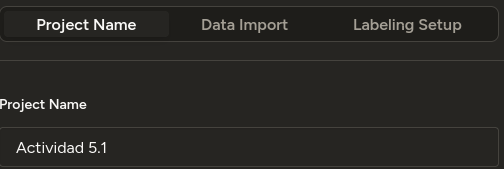

Después entramos a marcar las imagenes, para ello pondremos lo siguiente:

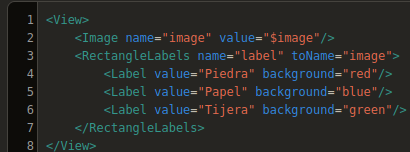

Aquí ya estamos marcando las imagenes

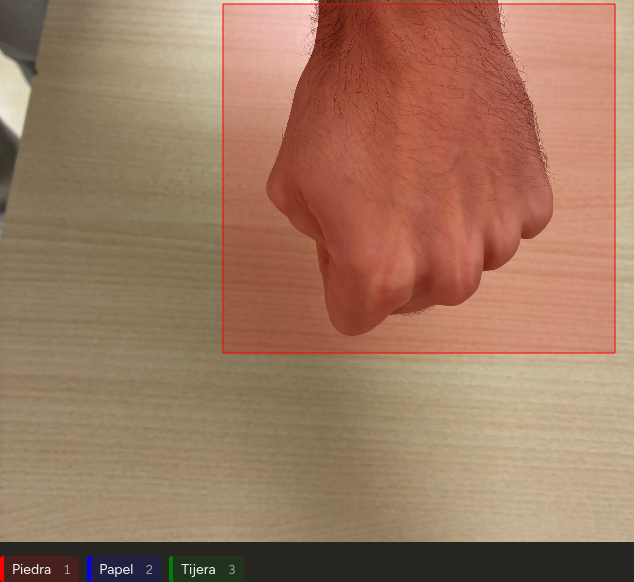

Empezamos con el entrenamiento, en primer lugar vamos a usar el modelo que hemos decargado.

In [20]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    device=0
)


New https://pypi.org/project/ultralytics/8.4.8 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimiz

Después de haber entrenado el modelo, recogeremos el resultado y comprobaremos si el entrenamiento fue bueno o no. Es decir, si de verdad sirve para poder identificar los 3 estados (piedra, papel o tijera).

In [28]:
from ultralytics import YOLO

model = YOLO("runs/detect/train2/weights/best.pt")
metrics = model.val(data="data.yaml", imgsz=640, device=0)


Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8603.4±936.0 MB/s, size: 467.7 KB)
val: Scanning /home/ciabd10/Descargas/curso-especializacion-big-data-ia/Modelos-Inteligencia-Artificial/Actividad_5.1/dataset/labels/val.cache... 7 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 54.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         11         11      0.873      0.975      0.995      0.739
                 Papel          5          7      0.814          1      0.995       0.76
                Piedra          2          2          1      0.924      0.995      0.661
                Tijera          2          2      0.806          1      0.995      0.796
Speed: 0.8ms preprocess, 2.7ms in

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
results = model("prueba.jpeg")

r = results[0]
r.show()                  # abre la ventana con las detecciones
r.save("resultado.jpg")   # guarda la imagen anotada



image 1/1 /home/ciabd10/Descargas/curso-especializacion-big-data-ia/Modelos-Inteligencia-Artificial/Actividad_5.1/prueba.jpeg: 640x640 2 Piedras, 1 Tijera, 6.0ms
Speed: 1.8ms preprocess, 6.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


'resultado.jpg'


** (gdk-pixbuf-thumbnailer:15582): WARNING **: 16:22:47.306: Could not thumbnail 'file:///tmp/.gnome_desktop_thumbnail.61V0J3': Falló al abrir el archivo «/tmp/.gnome_desktop_thumbnail.61V0J3»: No existe el archivo o el directorio

(xviewer:15434): CinnamonDesktop-WARNING **: 16:22:47.307: Unable to create an input stream for file:///tmp/.gnome_desktop_thumbnail.61V0J3: Error al abrir el archivo /tmp/.gnome_desktop_thumbnail.61V0J3: No existe el archivo o el directorio

** (gdk-pixbuf-thumbnailer:15796): WARNING **: 16:22:48.074: Could not thumbnail 'file:///tmp/.gnome_desktop_thumbnail.QALVJ3': Falló al abrir el archivo «/tmp/.gnome_desktop_thumbnail.QALVJ3»: No existe el archivo o el directorio

(xviewer:15434): CinnamonDesktop-WARNING **: 16:22:48.075: Unable to create an input stream for file:///tmp/.gnome_desktop_thumbnail.QALVJ3: Error al abrir el archivo /tmp/.gnome_desktop_thumbnail.QALVJ3: No existe el archivo o el directorio

** (gdk-pixbuf-thumbnailer:15800): WARNING **: 16

Despues de entrenar el modelo, podremos ver con la validacion, que el resultado es bastante bueno, ya que identifica con precision cada categoria. El resultado deberia de ser este.

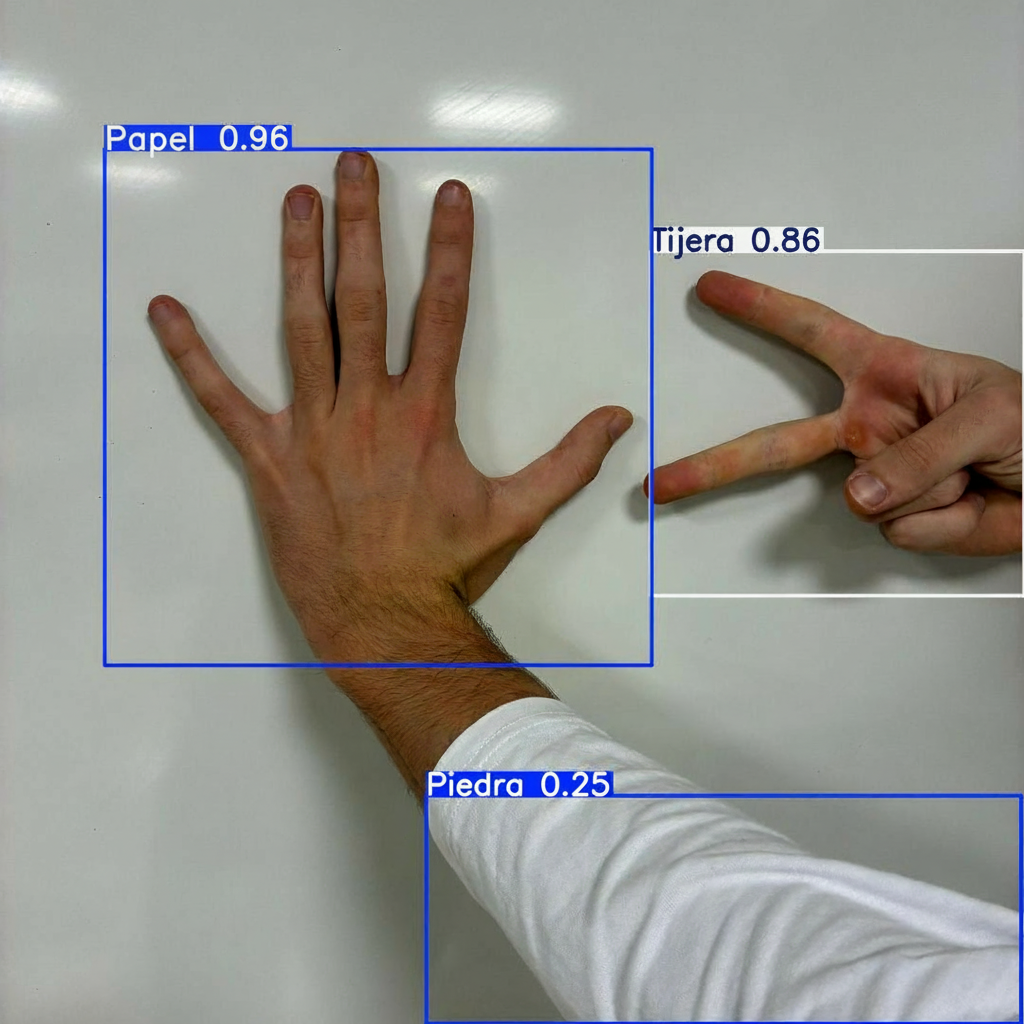